In [16]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from palettable.wesanderson import Darjeeling2_5
from prettytable import PrettyTable
from scipy.stats import chi2_contingency
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
import pickle
import joblib
from scipy import stats
warnings.filterwarnings('ignore')

In [118]:
def fa(model, labels , data , part) : 

    keys = [f'Factor_{i}' for i in range(1 , len(labels.keys())+1)]
    columns = [labels[key] for key in keys]

    data_cols = [col for col in data if col not in ['EVENT_ID' , 'PATNO'] and col[-3:] != 'TOT']
    factor_scores = model.transform(data[data_cols].dropna())  # Transform the original data set
    # Create a DataFrame from the scores
    factor_scores_df = pd.DataFrame(factor_scores, columns=columns).add_prefix(f'MDS_UPDRS_P{part}_')
    
    factor_scores_df['PATNO'] = data.dropna(subset=data_cols).reset_index(drop=True)['PATNO']
    factor_scores_df['EVENT_ID'] = data.dropna(subset=data_cols).reset_index(drop=True)['EVENT_ID']
    
    return factor_scores_df


def gen_factors(model = 'PPMI' , data='PPMI' , state='OFF' , model_state_off = False) : 
    with open(f'./../../data/02_processed/{data}/P1{state}_MDSUPDRS.pkl' , 'rb') as file : 
        p1 = pickle.load(file)

    with open(f'./../../data/02_processed/{data}/P2{state}_MDSUPDRS.pkl' , 'rb') as file : 
        p2 = pickle.load(file)
    
    with open(f'./../../data/02_processed/{data}/P3{state}_MDSUPDRS.pkl' , 'rb') as file : 
        p3 = pickle.load(file)
    
    model_p1 = joblib.load(f"./../../data/03_final/{model}_FA_model_P1.joblib")
    model_p2 = joblib.load(f"./../../data/03_final/{model}_FA_model_P2.joblib")
    if (state == 'On' or state == 'on') and model_state_off : 
        print(model)
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3OFF.joblib")
    else : 
        print(model)
        print(state)
        print('on')
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3{state}.joblib")

    p1_fa = fa(model_p1['fa'], model_p1['labels'] , p1 , '1')
    p2_fa = fa(model_p2['fa'], model_p2['labels'] , p2 , '2')
    p3_fa = fa(model_p3['fa'], model_p3['labels'] , p3 , '3')

    if data == 'PPMI' : 
        subgroups = pd.read_csv('./../../data/02_processed/PPMI/subgroups.csv', index_col=0)
        
    elif data == 'OPDC' : 
        subgroups = pd.read_csv('./../../data/02_processed/OPDC/subgroups.csv')

    elif data == 'TRACKING' : 
        subgroups = pd.read_csv('./../../data/02_processed/TRACKING/subgroups.csv' , index_col=0)
    
    return pd.merge((pd.merge(p1_fa , p2_fa , on = ['PATNO' , 'EVENT_ID'])), p3_fa , on = ['PATNO' , 'EVENT_ID']) , subgroups


def drop_sparse_time_bins(
    df: pd.DataFrame,
    *,
    min_patient_pct: float = 0.10,
    max_years: int | None = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Bin EVENT_ID into yearly intervals and drop bins where the number of unique
    patients falls below a minimum percentage of the total cohort.

    Parameters
    ----------
    df
        DataFrame containing at minimum 'PATNO' and 'EVENT_ID' columns.
    min_patient_pct
        Minimum fraction of total unique patients required to retain a bin.
        Default is 0.10 (10%).
    max_years
        Optional cap on the maximum year bin created. Inferred from data if not
        provided.
    verbose
        If True, print a summary table of kept/dropped bins.

    Returns
    -------
    pd.DataFrame
        A filtered copy of `df` with sparse time bins removed and a 'Year_Bin'
        column added.
    """
    # ── Validate ──────────────────────────────────────────────────────────────
    required = ("PATNO", "EVENT_ID")
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = df.copy().dropna(subset=["PATNO", "EVENT_ID"])

    # ── Bin into yearly intervals ─────────────────────────────────────────────
    if max_years is None:
        max_years = int(np.ceil(df["EVENT_ID"].max()))

    bins = np.arange(0, max_years + 1)  # 0,1,2,...,max_years

    df["Year_Bin"] = pd.cut(
        df["EVENT_ID"],
        bins=bins,
        labels=bins[:-1],  # floor year label: [0,1)→0, [1,2)→1, ...
        right=False,
    )

    df = df.dropna(subset=["Year_Bin"])
    df["Year_Bin"] = df["Year_Bin"].astype(int)

    # ── Compute unique patient counts per bin ────────────────────────────────
    total_patients = df["PATNO"].nunique()
    min_patients = int(np.ceil(total_patients * min_patient_pct))

    patients_per_bin = (
        df.groupby("Year_Bin", observed=True)["PATNO"]
        .nunique()
        .rename("n_patients")
    )

    valid_bins = patients_per_bin[patients_per_bin >= min_patients].index
    dropped_bins = patients_per_bin[patients_per_bin < min_patients]

    # ── Report ────────────────────────────────────────────────────────────────
    if verbose:
        print(f"Total unique patients : {total_patients}")
        print(f"Minimum required (≥{min_patient_pct:.0%}) : {min_patients}\n")

        print(f"{'Year Bin':<12} {'N Patients':>12} {'% Cohort':>10} {'Status':>10}")
        print("─" * 52)

        for yr, n in patients_per_bin.items():
            pct = 100 * n / total_patients if total_patients else np.nan
            status = "kept" if yr in valid_bins else "dropped"
            print(f"Year {yr}–{yr+1:<4}  {n:>12}  {pct:>9.1f}%  {status:>10}")

        if dropped_bins.empty:
            print("\nNo bins dropped.")

    # ── Filter ────────────────────────────────────────────────────────────────
    filtered = df[df["Year_Bin"].isin(valid_bins)].copy()

    if filtered.empty:
        raise ValueError("All bins dropped — lower min_patient_pct or inspect EVENT_ID range.")

    return filtered


In [141]:
df, subgroups = gen_factors(state='On' , data='TRACKING' , model='PPMI' , model_state_off=True)
df.drop(columns=['MDS_UPDRS_P3_NA'] , inplace=True)
#subgroups['LastLevodopa'] = subgroups['LastLevodopa'].fillna(24)
df['combo_A'] = df['MDS_UPDRS_P1_COGNITION'] + df['MDS_UPDRS_P3_PIG'] 
df['combo_B'] = df['MDS_UPDRS_P3_TREMOR'] + df['MDS_UPDRS_P3_TAPPING_R'] 
df['combo_C'] = df['MDS_UPDRS_P1_COGNITION'] + df['MDS_UPDRS_P3_TREMOR'] + df['MDS_UPDRS_P2_EAT'] 

PPMI


In [142]:
df = drop_sparse_time_bins(df)

Total unique patients : 1684
Minimum required (≥10%) : 169

Year Bin       N Patients   % Cohort     Status
────────────────────────────────────────────────────
Year 0–1             1409       83.7%        kept
Year 1–2             1123       66.7%        kept
Year 2–3              300       17.8%        kept
Year 3–4              660       39.2%        kept
Year 4–5              508       30.2%        kept
Year 5–6              134        8.0%     dropped
Year 6–7              180       10.7%        kept
Year 7–8               79        4.7%     dropped
Year 8–9               29        1.7%     dropped


── Baseline group sizes ─────────────────────────
Group
1    506
0    322
2    212

Reference (Subtype B) : 1
Comparison subtypes   : [0, 2]
Total observations    : 3074

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P1_FATIGUE
No. Observations: 3074    Method:             REML                
No. Groups:       1023    Scale:              0.2482              
Min. group size:  2       Log-Likelihood:     -3073.7213          
Max. group size:  25      Converged:          Yes                 
Mean group size:  3.0                                             
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.692    0.158  4.372 0.000  0.382  1.002
Time                     0.151    0.014 10.737 0.000  0.123  0.178
Time:C(Subtype)[T.0]    -0.007    0.023 

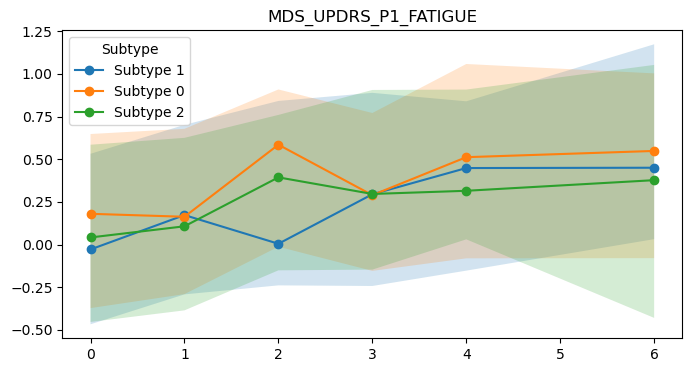

                      Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P1_DEPRESSION_plus_ANXIETY
No. Observations: 3074    Method:             REML                                
No. Groups:       1023    Scale:              0.4025                              
Min. group size:  2       Log-Likelihood:     -3652.7581                          
Max. group size:  25      Converged:          Yes                                 
Mean group size:  3.0                                                             
-------------------------------------------------------------------------------------
                            Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------------------
Intercept                    0.653       0.172     3.799    0.000     0.316     0.990
Time                         0.058       0.018     3.278    0.001     0.023     0.093
Time:C(Subty

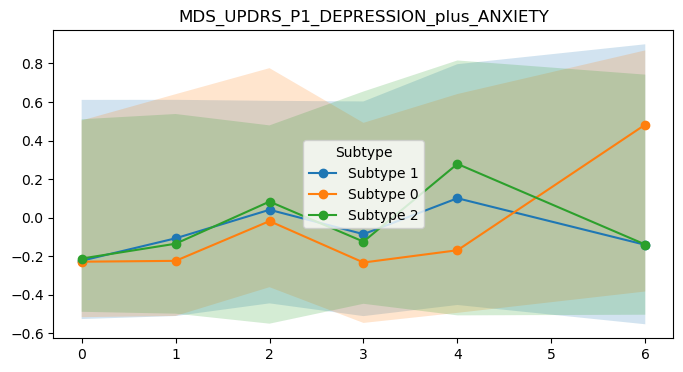

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P1_COGNITION
No. Observations: 3074    Method:             REML                  
No. Groups:       1023    Scale:              0.2682                
Min. group size:  2       Log-Likelihood:     -2996.6979            
Max. group size:  25      Converged:          Yes                   
Mean group size:  3.0                                               
---------------------------------------------------------------------
                      Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept             -1.104     0.136  -8.133  0.000  -1.371  -0.838
Time                   0.136     0.014   9.376  0.000   0.107   0.164
Time:C(Subtype)[T.0]   0.001     0.023   0.038  0.970  -0.045   0.047
Time:C(Subtype)[T.2]  -0.030     0.025  -1.197  0.231  -0.080   0.019
Sex                    0.126     0.038   3.

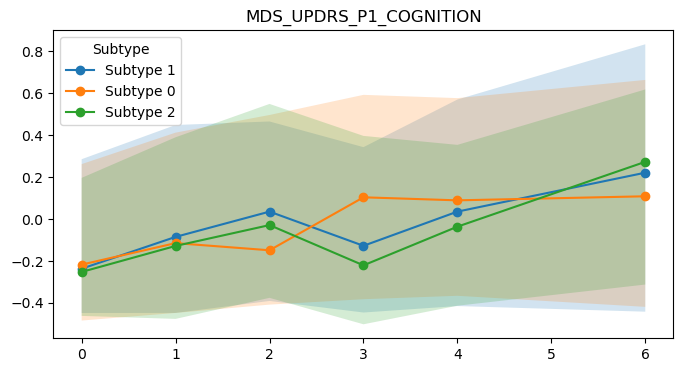

                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P2_RISE_plus_WALK
No. Observations: 3074    Method:             REML                       
No. Groups:       1023    Scale:              0.3111                     
Min. group size:  2       Log-Likelihood:     -3545.4911                 
Max. group size:  25      Converged:          Yes                        
Mean group size:  3.0                                                    
---------------------------------------------------------------------------
                       Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------------
Intercept              -0.717      0.200   -3.580   0.000   -1.110   -0.325
Time                    0.264      0.016   16.705   0.000    0.233    0.295
Time:C(Subtype)[T.0]    0.064      0.025    2.540   0.011    0.015    0.114
Time:C(Subtype)[T.2]   -0.008      0.028   -

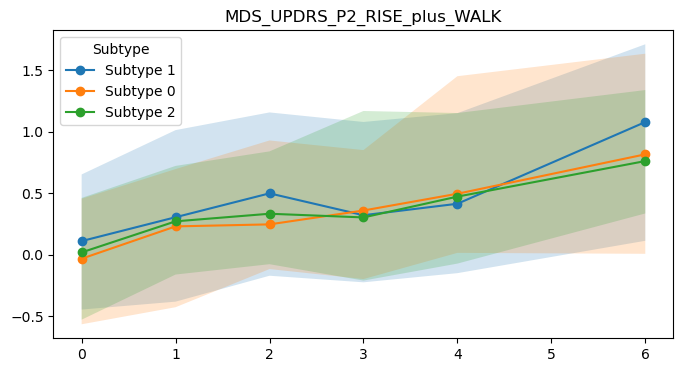

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P2_SPEECH
No. Observations: 3074    Method:             REML               
No. Groups:       1023    Scale:              0.2180             
Min. group size:  2       Log-Likelihood:     -2877.3727         
Max. group size:  25      Converged:          Yes                
Mean group size:  3.0                                            
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.331    0.149 -2.224 0.026 -0.622 -0.039
Time                    0.161    0.013 12.230 0.000  0.135  0.187
Time:C(Subtype)[T.0]    0.005    0.021  0.232 0.816 -0.037  0.046
Time:C(Subtype)[T.2]   -0.053    0.023 -2.303 0.021 -0.098 -0.008
Sex                     0.309    0.041  7.516 0.000  0.229  0.390
Age_BL                  

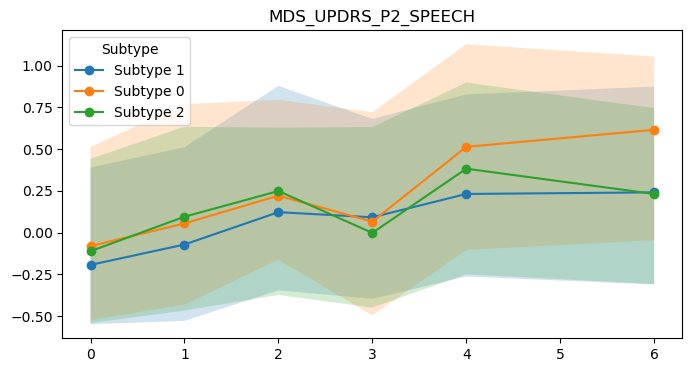

             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: MDS_UPDRS_P2_EAT
No. Observations:  3074    Method:             REML            
No. Groups:        1023    Scale:              0.3348          
Min. group size:   2       Log-Likelihood:     -3328.4734      
Max. group size:   25      Converged:          Yes             
Mean group size:   3.0                                         
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.017    0.150  0.110 0.912 -0.278  0.311
Time                  0.110    0.016  6.821 0.000  0.079  0.142
Time:C(Subtype)[T.0] -0.015    0.026 -0.589 0.556 -0.066  0.036
Time:C(Subtype)[T.2] -0.004    0.028 -0.152 0.879 -0.060  0.051
Sex                   0.171    0.042  4.107 0.000  0.089  0.252
Age_BL               -0.001    0.002 -0.659 0.510 -0.

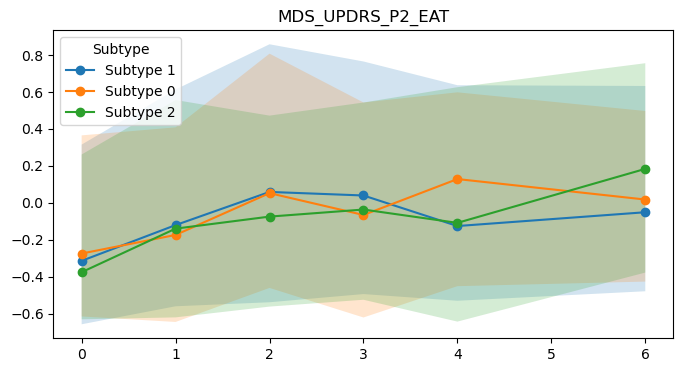

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P3_TAPPING_L
No. Observations: 3074    Method:             REML                  
No. Groups:       1023    Scale:              0.3438                
Min. group size:  2       Log-Likelihood:     -3497.3435            
Max. group size:  25      Converged:          Yes                   
Mean group size:  3.0                                               
---------------------------------------------------------------------
                      Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept              0.082     0.173   0.473  0.636  -0.257   0.421
Time                   0.079     0.016   4.807  0.000   0.047   0.112
Time:C(Subtype)[T.0]  -0.025     0.027  -0.931  0.352  -0.077   0.027
Time:C(Subtype)[T.2]   0.021     0.029   0.723  0.470  -0.036   0.077
Sex                    0.029     0.048   0.

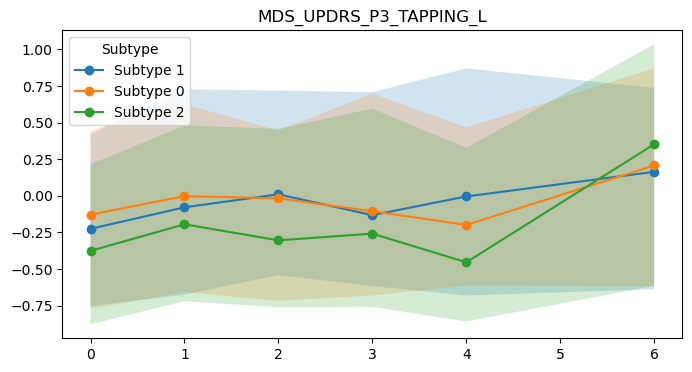

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P3_TAPPING_R
No. Observations: 3074    Method:             REML                  
No. Groups:       1023    Scale:              0.3443                
Min. group size:  2       Log-Likelihood:     -3556.1997            
Max. group size:  25      Converged:          Yes                   
Mean group size:  3.0                                               
---------------------------------------------------------------------
                      Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------
Intercept             -0.376     0.183  -2.057  0.040  -0.735  -0.018
Time                   0.071     0.017   4.318  0.000   0.039   0.104
Time:C(Subtype)[T.0]  -0.014     0.027  -0.515  0.607  -0.066   0.038
Time:C(Subtype)[T.2]   0.017     0.029   0.589  0.556  -0.040   0.073
Sex                   -0.006     0.051  -0.

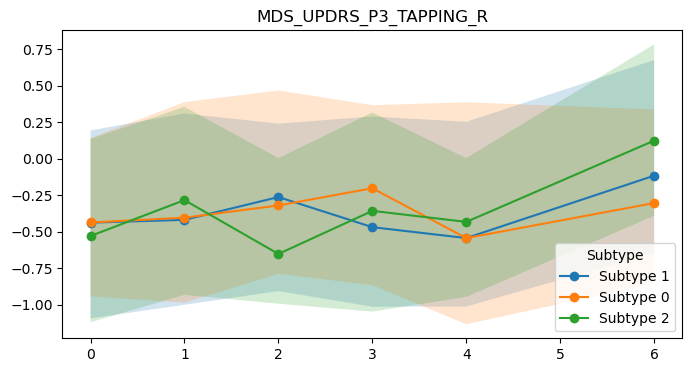

             Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: MDS_UPDRS_P3_PIG
No. Observations:  3074    Method:             REML            
No. Groups:        1023    Scale:              0.5757          
Min. group size:   2       Log-Likelihood:     -4291.0515      
Max. group size:   25      Converged:          Yes             
Mean group size:   3.0                                         
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -2.134    0.224 -9.513 0.000 -2.574 -1.695
Time                  0.316    0.021 14.809 0.000  0.274  0.358
Time:C(Subtype)[T.0] -0.005    0.034 -0.132 0.895 -0.072  0.063
Time:C(Subtype)[T.2] -0.053    0.037 -1.428 0.153 -0.126  0.020
Sex                  -0.087    0.062 -1.403 0.161 -0.209  0.035
Age_BL                0.040    0.003 11.922 0.000  0.

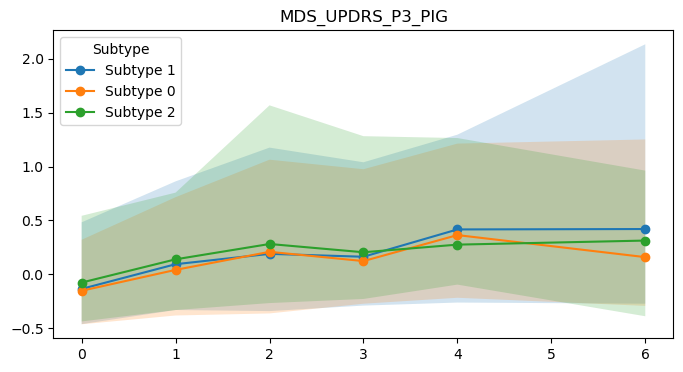

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P3_RISING
No. Observations: 3074    Method:             REML               
No. Groups:       1023    Scale:              0.4374             
Min. group size:  2       Log-Likelihood:     -3633.3836         
Max. group size:  25      Converged:          Yes                
Mean group size:  3.0                                            
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.193    0.155 -1.243 0.214 -0.497  0.111
Time                    0.075    0.018  4.076 0.000  0.039  0.111
Time:C(Subtype)[T.0]    0.012    0.030  0.406 0.685 -0.046  0.070
Time:C(Subtype)[T.2]   -0.023    0.032 -0.730 0.465 -0.086  0.039
Sex                     0.292    0.043  6.825 0.000  0.208  0.376
Age_BL                 -

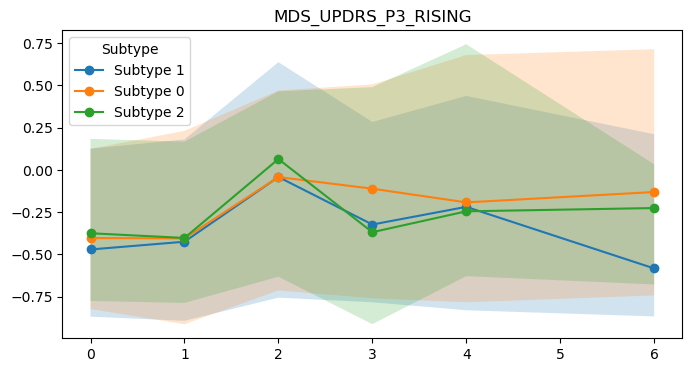

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: MDS_UPDRS_P3_TREMOR
No. Observations: 3074    Method:             REML               
No. Groups:       1023    Scale:              0.2993             
Min. group size:  2       Log-Likelihood:     -3278.0864         
Max. group size:  25      Converged:          Yes                
Mean group size:  3.0                                            
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.282    0.160 -1.758 0.079 -0.596  0.032
Time                   -0.025    0.015 -1.601 0.109 -0.055  0.006
Time:C(Subtype)[T.0]    0.012    0.025  0.483 0.629 -0.037  0.060
Time:C(Subtype)[T.2]    0.055    0.027  2.040 0.041  0.002  0.107
Sex                     0.049    0.044  1.113 0.266 -0.038  0.136
Age_BL                  

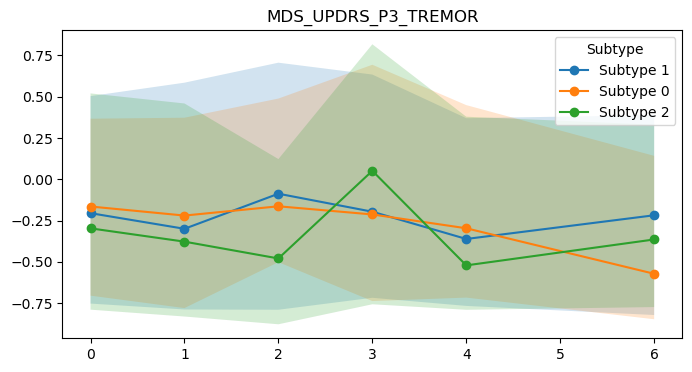

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   combo_A   
No. Observations:     3074      Method:               REML      
No. Groups:           1023      Scale:                0.9827    
Min. group size:      2         Log-Likelihood:       -5116.0414
Max. group size:      25        Converged:            Yes       
Mean group size:      3.0                                       
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -3.242    0.294 -11.007 0.000 -3.819 -2.664
Time                  0.454    0.028  16.264 0.000  0.399  0.509
Time:C(Subtype)[T.0] -0.003    0.045  -0.072 0.942 -0.091  0.085
Time:C(Subtype)[T.2] -0.082    0.049  -1.697 0.090 -0.178  0.013
Sex                   0.039    0.081   0.473 0.636 -0.121  0.198
Age_BL                0.057    0.004  1

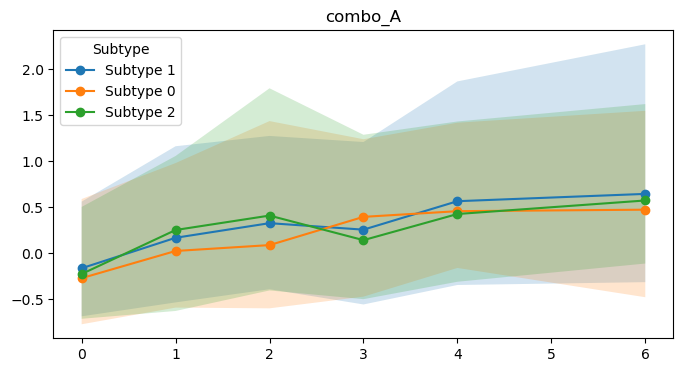

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   combo_B   
No. Observations:    3074      Method:               REML      
No. Groups:          1023      Scale:                0.5932    
Min. group size:     2         Log-Likelihood:       -4323.6863
Max. group size:     25        Converged:            Yes       
Mean group size:     3.0                                       
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -0.657    0.225 -2.921 0.003 -1.097 -0.216
Time                  0.046    0.022  2.141 0.032  0.004  0.089
Time:C(Subtype)[T.0] -0.002    0.035 -0.058 0.954 -0.070  0.066
Time:C(Subtype)[T.2]  0.072    0.038  1.911 0.056 -0.002  0.146
Sex                   0.043    0.062  0.698 0.485 -0.078  0.165
Age_BL                0.005    0.003  1.355 0.175 -0.

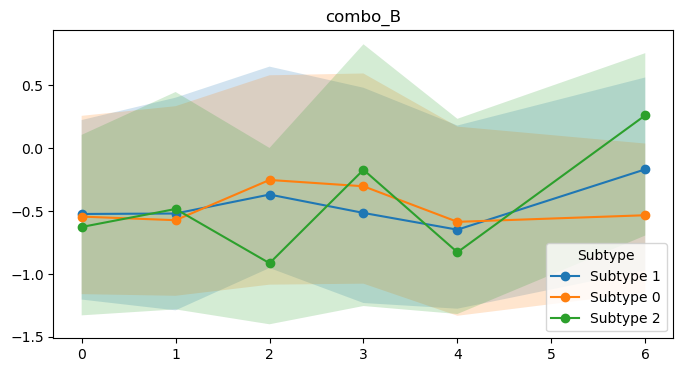

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   combo_C   
No. Observations:    3074      Method:               REML      
No. Groups:          1023      Scale:                1.0297    
Min. group size:     2         Log-Likelihood:       -5107.7029
Max. group size:     25        Converged:            Yes       
Mean group size:     3.0                                       
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -1.378    0.279 -4.944 0.000 -1.924 -0.832
Time                  0.223    0.028  7.851 0.000  0.168  0.279
Time:C(Subtype)[T.0] -0.003    0.046 -0.060 0.952 -0.092  0.087
Time:C(Subtype)[T.2]  0.020    0.050  0.394 0.693 -0.078  0.117
Sex                   0.346    0.077  4.487 0.000  0.195  0.497
Age_BL                0.018    0.004  4.367 0.000  0.

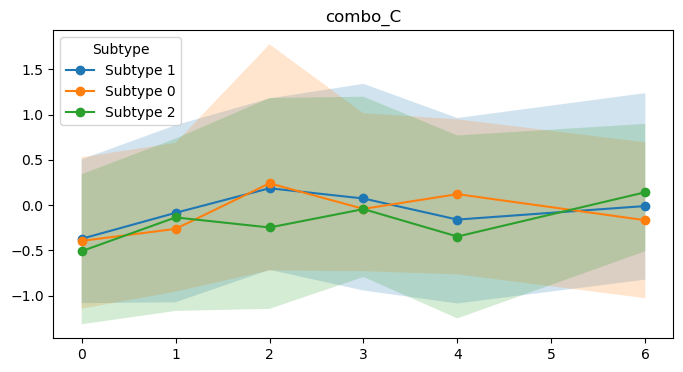

Empty DataFrame
Columns: [factor, subtype_vs_B, coef_type, estimate, ci_lower, ci_upper, q_value, marginal_r2]
Index: []


In [143]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Column definitions
# ══════════════════════════════════════════════════════════════════════════════
FACTOR_COLS = [
    "MDS_UPDRS_P1_FATIGUE",
    "MDS_UPDRS_P1_DEPRESSION+ANXIETY",
    "MDS_UPDRS_P1_COGNITION",
    "MDS_UPDRS_P2_RISE+WALK",
    "MDS_UPDRS_P2_SPEECH",
    "MDS_UPDRS_P2_EAT",
    "MDS_UPDRS_P3_TAPPING_L",
    "MDS_UPDRS_P3_TAPPING_R",
    "MDS_UPDRS_P3_PIG",
    "MDS_UPDRS_P3_RISING",
    "MDS_UPDRS_P3_TREMOR",
    "combo_A",
    "combo_B",
    "combo_C"
]

def _sanitize(name: str) -> str:
    """Replace patsy-unsafe characters so column names work inside formulas."""
    return (name.replace("+", "_plus_")
                .replace("-", "_minus_")
                .replace(" ", "_"))

FACTOR_RENAME = {col: _sanitize(col) for col in FACTOR_COLS}   # original → safe
FACTOR_SAFE   = list(FACTOR_RENAME.values())
SAFE_TO_ORIG  = {v: k for k, v in FACTOR_RENAME.items()}       # safe → original


# ══════════════════════════════════════════════════════════════════════════════
# 2. Marginal R² (Nakagawa & Schielzeth, 2013)
# ══════════════════════════════════════════════════════════════════════════════
def marginal_r2(result) -> float:
    """
    R²_marginal = σ²_f / (σ²_f + σ²_random + σ²_residual)
    where σ²_f is the variance of the fixed-effect predictions.
    """
    fe_pred  = result.model.exog @ result.fe_params   # fixed-effect predictions only
    sigma2_f = float(np.var(fe_pred, ddof=0))
    sigma2_r = float(np.trace(result.cov_re))         # sum of random-effect variances
    sigma2_e = float(result.scale)                    # residual variance
    total    = sigma2_f + sigma2_r + sigma2_e
    return sigma2_f / total if total > 0 else np.nan


# ══════════════════════════════════════════════════════════════════════════════
# 3. Single model fitter with convergence guard
# ══════════════════════════════════════════════════════════════════════════════
def _fit_lme(data: pd.DataFrame,
             outcome: str,
             groups: pd.Series,
             re_formula=None) -> tuple:
    """
    Fit one MixedLM; returns (result, converged_bool).

    re_formula='~0+Time'  →  random slope only, NO intercept  (0 + Time | Patient)
    re_formula='~Time'    →  random intercept + slope          (1 + Time | Patient)
    """
    formula = f"{outcome} ~ Time + Time:C(Subtype) + Sex +Age_BL"
    
    # Scale continuous predictors to help convergence
    data = data.copy()
    time_mean, time_std = data["Time"].mean(), data["Time"].std()
    #age_mean,  age_std  = data["Age"].mean(),  data["Age"].std()
    data["Time"] = (data["Time"] - time_mean) / time_std
    #data["Age"]  = (data["Age"]  - age_mean)  / age_std

    # Ordered from most to least aggressive in finding convergence
    fit_configs = [
        {"method": "lbfgs", "maxiter": 200, "gtol": 1e-4, "reml": True,  "niter_em": 0  },
        {"method": "lbfgs", "maxiter": 500, "gtol": 1e-3, "reml": True,  "niter_em": 25 },
        {"method": "cg",    "maxiter": 500, "gtol": 1e-3, "reml": True,  "niter_em": 25 },
        {"method": "nm",    "maxiter": 500, "gtol": 1e-2, "reml": False, "niter_em": 25 },
        {"method": "powell","maxiter": 500, "gtol": 1e-2, "reml": False, "niter_em": 50 },
    ]

    for cfg in fit_configs:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model  = smf.mixedlm(formula, data, groups=groups,
                                     re_formula=re_formula)
                result = model.fit(disp=False, **cfg)
                print(result.summary())
            converged = bool(getattr(result, "converged", True))
            if converged:
                return result, True
        except Exception:
            continue

    # Return last attempt even if not converged
    try:
        return result, False
    except Exception:
        return None, False

def slope_contrast(result, key_a: str, key_b: str):
    """
    Test (beta[key_a] - beta[key_b]) using delta method.
    Returns (estimate, se, z, p, ci_low, ci_high).
    """
    params = result.params
    cov    = result.cov_params()

    est = params[key_a] - params[key_b]
    var = cov.loc[key_a, key_a] + cov.loc[key_b, key_b] - 2 * cov.loc[key_a, key_b]
    se  = float(np.sqrt(var))

    z = float(est / se) if se > 0 else np.nan
    p = float(2 * stats.norm.sf(abs(z))) if np.isfinite(z) else np.nan

    ci_low  = float(est - 1.96 * se)
    ci_high = float(est + 1.96 * se)

    return est, se, z, p, ci_low, ci_high
# ══════════════════════════════════════════════════════════════════════════════
# 4. Data preparation
# ══════════════════════════════════════════════════════════════════════════════
def prepare_data(df_factors: pd.DataFrame,
                 df_demo:    pd.DataFrame,
                 cohort_patnos=None) -> tuple:
    """
    Merge factor scores with demographics, compute time since baseline,
    and set up a reference-coded Subtype column (largest group = B = reference).

    Parameters
    ----------
    df_factors    : factor-score dataframe (PATNO, EVENT_ID, 11 factor columns)
    df_demo       : demographic dataframe  (PATNO, EVENT_ID, Group,
                                            AGE_AT_VISIT, GENDER)
    cohort_patnos : optional set/list of PATNOs to restrict to (e.g. PPMI only)
    """
    factors_safe = df_factors.rename(columns=FACTOR_RENAME)

    if cohort_patnos is not None:
        factors_safe = factors_safe[factors_safe["PATNO"].isin(cohort_patnos)]
        df_demo      = df_demo[df_demo["PATNO"].isin(cohort_patnos)]

    df = pd.merge(factors_safe, df_demo, on=["PATNO", "EVENT_ID"], how="inner")

    # ── Time = AGE_AT_VISIT − baseline AGE_AT_VISIT (years since BL) ──────────
    bl_ages = (
        df.loc[df["EVENT_ID"] == 0, ["PATNO", "AGE_AT_VISIT"]]
          .drop_duplicates("PATNO")
          .rename(columns={"AGE_AT_VISIT": "BL_AGE"})
    )

    missing_bl = set(df["PATNO"].unique()) - set(bl_ages["PATNO"])
    if missing_bl:
        warnings.warn(f"{len(missing_bl)} patient(s) lack a BL visit; "
                      "their observations will be excluded.")

    df = df.merge(bl_ages, on="PATNO", how="left")
    df["Time"] = df["AGE_AT_VISIT"] - df["BL_AGE"]
    df["Age_BL"] = df["BL_AGE"]   # baseline age covariate

    df = df.rename(columns={
        "PATNO":        "Patient",
        "AGE_AT_VISIT": "Age",
        "GENDER":       "Sex",
    })

    # Drop rows missing modelling variables
    df = df.dropna(subset=["Time", "Age", "Sex", "Group"])

    # Drop patients with only one observation (cannot estimate within-patient slope)
    n_obs = df.groupby("Patient")["Time"].transform("count")
    df    = df[n_obs >= 2].copy()

    # ── Reference-code Subtype: largest group = B = first / reference category ─
    bl_counts = df.loc[df["EVENT_ID"] == 0, "Group"].value_counts()
    ref_group = bl_counts.idxmax()                            # Subtype B
    others    = [g for g in bl_counts.index if g != ref_group]

    df["Subtype"] = pd.Categorical(
        df["Group"], categories=[ref_group] + others, ordered=False
    )

    print("── Baseline group sizes ─────────────────────────")
    print(bl_counts.to_string())
    print(f"\nReference (Subtype B) : {ref_group}")
    print(f"Comparison subtypes   : {others}")
    print(f"Total observations    : {len(df)}\n")

    return df, ref_group, others


# ══════════════════════════════════════════════════════════════════════════════
# 5. Main analysis
# ══════════════════════════════════════════════════════════════════════════════
def run_lme_analysis(df_factors:    pd.DataFrame,
                     df_demo:       pd.DataFrame,
                     cohort:        str = "PPMI",
                     cohort_patnos       = None) -> pd.DataFrame:
    """
    Between-subtype trajectory analysis via linear mixed-effects models.

    Model (Eq. 1):
        Phenotype ~ Time × Subtype + Age + Sex + (1 + Time | Patient)

    - Subtype B (largest group, ~50 %) is the reference category.
    - Slope and intercept differences for subtypes A and C vs. B are extracted.
    - Fallback to random-intercept-only if the random-slope model fails to converge.
    - p-values corrected with Benjamini–Hochberg FDR across all 44 tests.
    - Factors with marginal R² < 0.10 are flagged.

    Returns
    -------
    pd.DataFrame with one row per (factor × subtype comparison × coefficient type)
    """
    df, ref_group, other_groups = prepare_data(df_factors, df_demo, cohort_patnos)
    rows = []

    for factor_safe in FACTOR_SAFE:
        orig_name   = SAFE_TO_ORIG[factor_safe]
        cols_needed = ["Patient", "Time", "Age", "Sex", "Subtype", "Age_BL", factor_safe]
        dff         = df[cols_needed].dropna()

        if dff["Subtype"].nunique() < 2:
            warnings.warn(f"[{orig_name}] Fewer than 2 subtypes after NA removal — skipping.")
            continue

        # ── Attempt 1: random intercept + slope ──────────────────────────────
        result, converged = _fit_lme(dff, factor_safe, dff["Patient"],
                                     re_formula=None)

        if result is None:
            warnings.warn(f"[{orig_name}] Both model variants failed — skipping.")
            continue

        r2m    = marginal_r2(result)
        params = result.params
        pvals  = result.pvalues
        ci     = result.conf_int()

        # ── Extract intercept and slope coefficients for each non-B subtype ──
        for grp in other_groups:
            for coef_type, primary_key in [
                ("slope",     f"Time:C(Subtype)[T.{grp}]"),
            ]:
                key = primary_key
                # Patsy occasionally reverses interaction term order
                if key not in params.index:
                    alt = f"C(Subtype)[T.{grp}]:Time"
                    if alt in params.index:
                        key = alt
                    else:
                        warnings.warn(f"[{orig_name}] '{primary_key}' not found in model output.")
                        continue

                rows.append({
                    "cohort":       cohort,
                    "factor":       orig_name,
                    "subtype_vs_B": f"{grp}_vs_{ref_group}",
                    "coef_type":    coef_type,           # 'intercept' or 'slope'
                    "estimate":     params[key],
                    "ci_lower":     ci.loc[key, 0],
                    "ci_upper":     ci.loc[key, 1],
                    "p_value":      pvals[key],
                    "marginal_r2":  r2m,
                    "converged":    converged,
                })

        # ── Add 0 vs 2 slope comparison (if both exist) ───────────────────────
        # Find the actual level strings used in the model output
        # (your output uses "T.0.0" and "T.2.0")
        k0 = "Time:C(Subtype)[T.0]"
        k2 = "Time:C(Subtype)[T.2]"

        if k0 not in params.index and "C(Subtype)[T.0]:Time" in params.index:
            k0 = "C(Subtype)[T.0]:Time"
        if k2 not in params.index and "C(Subtype)[T.2]:Time" in params.index:
            k2 = "C(Subtype)[T.2]:Time"

        if k0 in params.index and k2 in params.index:
            est, se, z, p, lo, hi = slope_contrast(result, k0, k2)

            rows.append({
                "cohort":       cohort,
                "factor":       orig_name,
                "subtype_vs_B": "0_vs_2",   # rename this column if you want
                "coef_type":    "slope",
                "estimate":     est,
                "ci_lower":     lo,
                "ci_upper":     hi,
                "p_value":      p,
                "marginal_r2":  r2m,
                "converged":    converged,
            })
        else:
            warnings.warn(f"[{orig_name}] Could not compute 0 vs 2 slope contrast (missing keys).")
        
        d = dff.dropna(subset=["Time", "Subtype", factor_safe]).copy()
        d["Year_Bin"] = np.floor(d["Time"]).astype(int)
        
        # median + IQR per (Subtype, Year_Bin)
        s = (
            d.groupby(["Subtype", "Year_Bin"])[factor_safe]
             .agg(median="median",
                  q25=lambda x: x.quantile(0.25),
                  q75=lambda x: x.quantile(0.75))
             .reset_index()
        )
        
        # plot one line per subtype with IQR shading
        fig, ax = plt.subplots(figsize=(8, 4))
        plt.title(factor_safe)
        for st, g in s.groupby("Subtype"):
            g = g.sort_values("Year_Bin")
            ax.plot(g["Year_Bin"], g["median"], marker="o", label=f"Subtype {st}")
            ax.fill_between(g["Year_Bin"], g["q25"], g["q75"], alpha=0.2)
        ax.legend(title="Subtype")
        plt.show()

    # ── Post-processing ───────────────────────────────────────────────────────
    results = pd.DataFrame(rows)

    if results.empty:
        warnings.warn("No results produced — returning empty DataFrame.")
        return results

    # Benjamini–Hochberg FDR across all 44 tests (11 factors × 2 subtypes × 2 coefs)
    reject, q_vals, _, _ = multipletests(results["p_value"].values, method="fdr_bh")
    results["q_value"]       = q_vals
    results["sig_q05"]       = reject              # True if q < 0.05
    results["r2_sufficient"] = results["marginal_r2"] >= 0.10   # flag low-R² factors

    return results


# ══════════════════════════════════════════════════════════════════════════════
# 6. Run & inspect
# ══════════════════════════════════════════════════════════════════════════════
results = run_lme_analysis(df, subgroups, cohort="PPMI")

# Significant results that also pass the R² threshold
sig = results[results["sig_q05"]]

print(sig[[
    "factor", "subtype_vs_B", "coef_type",
    "estimate", "ci_lower", "ci_upper",
    "q_value", "marginal_r2", 
]].to_string(index=False))


In [144]:
results[results['p_value'] < 0.1]

,cohort,factor,subtype_vs_B,coef_type,estimate,ci_lower,ci_upper,p_value,marginal_r2,converged,q_value,sig_q05,r2_sufficient
9,PPMI,MDS_UPDRS_P2_RISE+WALK,0_vs_1,slope,0.064488,0.014718,0.114259,0.011099,0.101302,True,0.223244,False,True
11,PPMI,MDS_UPDRS_P2_RISE+WALK,0_vs_2,slope,0.072557,0.013631,0.131483,0.015805,0.101302,True,0.223244,False,True
13,PPMI,MDS_UPDRS_P2_SPEECH,2_vs_1,slope,-0.052869,-0.097857,-0.007881,0.021261,0.080365,True,0.223244,False,False
14,PPMI,MDS_UPDRS_P2_SPEECH,0_vs_2,slope,0.057786,0.008630,0.106942,0.021216,0.080365,True,0.223244,False,False
31,PPMI,MDS_UPDRS_P3_TREMOR,2_vs_1,slope,0.054711,0.002157,0.107265,0.041309,0.002621,True,0.346998,False,False
34,PPMI,combo_A,2_vs_1,slope,-0.082488,-0.177757,0.012781,0.089692,0.160199,True,0.470881,False,True
37,PPMI,combo_B,2_vs_1,slope,0.072126,-0.001843,0.146095,0.055987,0.005180,True,0.391912,False,False
38,PPMI,combo_B,0_vs_2,slope,-0.074146,-0.154973,0.006680,0.072176,0.005180,True,0.433056,False,False


In [151]:
results_plot = results[results['factor'].isin(results[results['p_value'] < 0.05]['factor'].unique())]

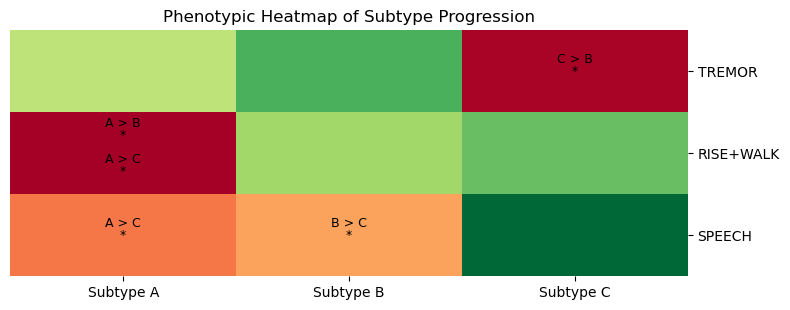

In [153]:
df = results_plot.copy()

# 1) extract A and B from "subtype_vs_B" (e.g., "0.0_vs_1.0" -> A=0, B=1)
ab = df["subtype_vs_B"].str.extract(r'(?P<A>\d+(?:\.\d+)?)_vs_(?P<B>\d+(?:\.\d+)?)').astype(float).astype(int)
df2 = df.join(ab)

# 2) keep slopes only (optional)
df2 = df2[df2["coef_type"].eq("slope")].copy()

# 3) choose baseline subtype (here 1) and build subtype-specific values
baseline = 1

# rows for A_vs_baseline give value(A) directly
dA = df2[df2["B"].eq(baseline)][["factor", "A", "estimate"]].rename(columns={"A": "subtype"})

# rows for baseline_vs_B would imply value(B) = -estimate (not needed if you already have *_vs_1)
dB = df2[df2["A"].eq(baseline)][["factor", "B", "estimate"]].assign(estimate=lambda x: -x["estimate"]) \
       .rename(columns={"B": "subtype"})

# baseline itself
factors = pd.Index(df2["factor"].unique(), name="factor")
dBase = pd.DataFrame({"factor": factors, "subtype": baseline, "estimate": 0.0})

long = pd.concat([dA, dB, dBase], ignore_index=True)

# 4) pivot to the requested layout: index=factor, columns=subtype (0/1/2)
wide = (long.pivot_table(index="factor", columns="subtype", values="estimate", aggfunc="first")
             .reindex(columns=[0, 1, 2])
       )

wide.columns = ['Subtype A', 'Subtype B' , 'Subtype C']

baseline = 1

df2 = df.copy()
ab = df2["subtype_vs_B"].str.extract(r'(?P<A>\d+(?:\.\d+)?)_vs_(?P<B>\d+(?:\.\d+)?)').astype(float).astype(int)
df2 = df2.join(ab)

df2 = df2[df2["coef_type"].eq("slope")].copy()

# p-values for A_vs_baseline go to subtype A
pA = df2[df2["B"].eq(baseline)][["factor", "A", "p_value"]].rename(columns={"A": "subtype"})

# if you also have baseline_vs_B, those map to subtype B, but p-value is the same test
pB = df2[df2["A"].eq(baseline)][["factor", "B", "p_value"]].rename(columns={"B": "subtype"})

pBase = pd.DataFrame({"factor": df2["factor"].unique(), "subtype": baseline, "p_value": np.nan})

p_long = pd.concat([pA, pB, pBase], ignore_index=True)

p_wide = (p_long.pivot_table(index="factor", columns="subtype", values="p_value", aggfunc="first")
                .reindex(index=wide.index, columns=[0,1,2]))

def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = p_wide.applymap(p_to_stars)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df = your long dataframe

alpha = 0.05
use_q = True          # set False to use p_value instead
baseline_only = False # True if you ONLY want comparisons involving baseline (e.g. *_vs_1)

val_col = "q_value" if use_q else "p_value"

d = df[df["coef_type"].eq("slope")].copy()

# parse A and B from "subtype_vs_B"
ab = d["subtype_vs_B"].str.extract(r'(?P<A>\d+(?:\.\d+)?)_vs_(?P<B>\d+(?:\.\d+)?)')
d["A"] = ab["A"].astype(float).astype(int)
d["B"] = ab["B"].astype(float).astype(int)

if baseline_only:
    baseline = 1
    d = d[(d["A"].eq(baseline)) | (d["B"].eq(baseline))]

# keep only significant tests
sig = d[d[val_col] < alpha].copy()

# direction: estimate>0 => A>B else A<B (equivalently B>A)
def relation(row):
    if row["estimate"] > 0:
        return f'{row["A"]} > {row["B"]}'
    else:
        return f'{row["B"]} > {row["A"]}'

sig["relation"] = sig.apply(relation, axis=1)

# collapse per factor into a single label string
rel_by_factor = (sig.groupby("factor")["relation"]
                   .apply(lambda s: ", ".join(sorted(set(s))))
                   .reindex(wide.index)
                   .fillna(""))
rel_by_factor


wide

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

alpha = 0.05
use_q = False           # use q_value instead of p_value
val_col = "q_value" if use_q else "p_value"

def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# --- Parse comparisons and keep slopes ---
d = df[df["coef_type"].eq("slope")].copy()
ab = d["subtype_vs_B"].str.extract(r'(?P<A>\d+(?:\.\d+)?)_vs_(?P<B>\d+(?:\.\d+)?)')
d["A"] = ab["A"].astype(float).astype(int)
d["B"] = ab["B"].astype(float).astype(int)

# --- Keep only significant tests ---
sig = d[d[val_col] < alpha].copy()

# Determine winner/loser for each significant comparison
# estimate > 0 => A > B, else B > A
sig["winner"] = np.where(sig["estimate"] > 0, sig["A"], sig["B"])
sig["loser"]  = np.where(sig["estimate"] > 0, sig["B"], sig["A"])
sig["stars"]  = sig[val_col].map(p_to_stars)

# --- Build a per-cell annotation table aligned to `wide` ---
# We will annotate the *winner* subtype cell with arrow and stars.
# If multiple comparisons point to the same winner cell, we concatenate.
arrow = "> "   # use ">" if you prefer textual, but arrow reads better in-cell

ann = pd.DataFrame("", index=wide.index, columns=[0,1,2], dtype=object)

subtypes = ['A' , 'B' , 'C']

for r in sig.itertuples(index=False):
    factor = r.factor
    w = int(r.winner)
    l = int(r.loser)

    if factor in ann.index and w in ann.columns:
        piece = f"{subtypes[w]} {arrow}{subtypes[l]}\n{r.stars}\n"   # arrow+loser above, stars below
        ann.loc[factor, w] = (ann.loc[factor, w] + ("\n" if ann.loc[factor, w] else "") + piece)

# --- Draw clustermap without dendrograms/legend ---
wide_plt = wide.iloc[: , :].copy()
#wide_plt.index =  ['_'.join(i.replace('RISING' , 'RIGIDITY').split('_')[3:]) for i in wide_plt.index[:-2]] + ['PIG + Cognition','Tremor + Tapping']
wide_plt.index =  ['_'.join(i.replace('RISING' , 'RIGIDITY').split('_')[3:]) for i in wide_plt.index] 
g = sns.clustermap(
    wide_plt,
    cmap="RdYlGn_r",
    figsize=(8, 3),
    metric="euclidean",
    z_score=0,
    col_cluster=False,
    row_cluster=True,
    dendrogram_ratio=(0.0, 0.0),
    cbar_pos=None,
)

# Reorder annotations to match clustered row order
row_order = g.dendrogram_row.reordered_ind if g.dendrogram_row is not None else np.arange(wide.shape[0])
ann_plot = ann.iloc[row_order, :]
ann_plot.columns = ['Subtype A' , 'Subtype B' , 'Subtype C']

# Overlay per-cell text: arrow+loser on top line, stars on bottom line
ax = g.ax_heatmap
for i in range(ann_plot.shape[0]):
    for j in range(ann_plot.shape[1]):
        txt = ann_plot.iat[i, j]
        if txt:
            ax.text(j + 0.5, i + 0.5, txt, ha="center", va="center",
                    fontsize=9, color="black", linespacing=0.9)

ax = g.ax_heatmap

ax.tick_params(axis="y", labelrotation=0)

ax.set_xlabel("")
ax.set_ylabel("")
plt.title('Phenotypic Heatmap of Subtype Progression')
plt.savefig("./../Results/trck_val_pheno.svg")
plt.show()


In [150]:
stars

subtype,0,1,2
factor,,,
MDS_UPDRS_P2_RISE+WALK,*,,
MDS_UPDRS_P2_SPEECH,,,*
MDS_UPDRS_P3_TREMOR,,,*
combo_A,,,
combo_B,,,


In [148]:
wide

,Subtype A,Subtype B,Subtype C
factor,,,
MDS_UPDRS_P2_RISE+WALK,0.064488,0.0,-0.008068
MDS_UPDRS_P2_SPEECH,0.004917,0.0,-0.052869
MDS_UPDRS_P3_TREMOR,0.011941,0.0,0.054711
combo_A,-0.003241,0.0,-0.082488
combo_B,-0.002020,0.0,0.072126
